In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Load Data From Kaggle
https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-segmentation-2026

In [47]:
from pathlib import Path

path = kagglehub.dataset_download(
    "datascikhan/e-commerce-customer-segmentation-2026"
)
print("Path to dataset files:", path)

data_dir = Path(path)
csv_files = list(data_dir.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

df = pd.read_csv(csv_files[0])

Path to dataset files: /Users/yezawmyint/.cache/kagglehub/datasets/datascikhan/e-commerce-customer-segmentation-2026/versions/1


# Understanding data

In [48]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(column_info)

Rows: 50,000
Columns: 53


,Column Name,Data Type
0,customer_id,str
1,customer_segment,str
2,segment_category,str
3,age,int64
4,age_group,str
5,gender,str
6,country,str
7,city,str
8,income_bracket,str
9,education_level,str


## Check Data Validation

In [49]:
# Missing values
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})
print("*"*30)
print(" Missing Value Summary")
print("*"*30)

display(
    missing_summary
    .sort_values("Missing Values", ascending=False)
    .head(15)
)

******************************
 Missing Value Summary
******************************


,Missing Values,Missing %
preferred_category_3,33257,66.51
preferred_category_2,16743,33.49
social_media_presence,12420,24.84
loyalty_tier,1272,2.54
customer_id,0,0.00
rfm_score,0,0.00
click_through_rate,0,0.00
conversion_rate,0,0.00
customer_lifetime_value_usd,0,0.00
customer_acquisition_cost_usd,0,0.00


In [50]:
# What kind of NULL are they
df[df.isnull().any(axis=1)]

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
5,CUST-000006,Consumer,High Value Active,41,35-44,Male,France,Toulouse,50K-75K,PhD,...,High,Active,Excellent,Very Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49991,CUST-049992,Small Business,Medium Value Inactive,25,25-34,Male,Mexico,Puebla,50K-75K,PhD,...,Low,Active,Excellent,Low,Potential Loyalists,High Profit,Medium,Occasional Buyer,Multi-Device,Medium CLV
49993,CUST-049994,Consumer,High Value Inactive,55,55-64,Male,France,Montpellier,0-25K,Masters,...,High,Inactive,Fair,High,Potential Loyalists,High Profit,High,Occasional Buyer,Mobile-First,High CLV
49995,CUST-049996,Small Business,Low Value,22,18-24,Female,United States,San Antonio,50K-75K,PhD,...,Very Low,Inactive,Fair,High,Need Attention,High Profit,Low,Occasional Buyer,Multi-Device,Low CLV
49996,CUST-049997,Small Business,High Value Inactive,24,18-24,Male,Brazil,Rio de Janeiro,25K-50K,PhD,...,Very High,Dormant,Excellent,Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV


In [51]:
# Check Duplication
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count:,}")


Duplicate Rows: 0


In [52]:
# Summary
print("*"*30)
print("Summary Statistics")
print("*"*30)
df.describe().T

******************************
Summary Statistics
******************************


,count,mean,std,min,25%,50%,75%,max
age,50000.0,45.648020,18.367950,18.00,30.0000,45.000,60.00000,84.00
tenure_months,50000.0,59.748240,34.310128,1.00,30.0000,60.000,90.00000,119.00
total_purchases,50000.0,99.418460,57.780178,0.00,49.0000,99.000,150.00000,199.00
avg_order_value_usd,50000.0,505.366911,285.604037,10.05,259.0675,504.790,752.70250,999.99
total_spent_usd,50000.0,50266.546156,44071.209164,0.00,13893.5775,37541.625,76811.24250,198574.14
days_since_last_purchase,50000.0,62.971240,93.281404,0.00,2.0000,19.000,77.00000,365.00
return_count,50000.0,9.511740,5.782592,0.00,4.0000,10.000,15.00000,19.00
complaint_count,50000.0,6.993800,4.324250,0.00,3.0000,7.000,11.00000,14.00
satisfaction_score,50000.0,3.007960,1.417976,1.00,2.0000,3.000,4.00000,5.00
email_open_rate,50000.0,0.500319,0.289515,0.00,0.2510,0.500,0.75200,1.00


In [53]:
# Top 5 rows
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [54]:
# Bottom 5 rows
df.tail()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
49995,CUST-049996,Small Business,Low Value,22,18-24,Female,United States,San Antonio,50K-75K,PhD,...,Very Low,Inactive,Fair,High,Need Attention,High Profit,Low,Occasional Buyer,Multi-Device,Low CLV
49996,CUST-049997,Small Business,High Value Inactive,24,18-24,Male,Brazil,Rio de Janeiro,25K-50K,PhD,...,Very High,Dormant,Excellent,Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV
49997,CUST-049998,Consumer,High Value Inactive,29,25-34,Female,France,Strasbourg,100K-150K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
49998,CUST-049999,Consumer,High Value Active,74,65+,Male,Italy,Catania,100K-150K,Bachelors,...,High,Active,Good,Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
49999,CUST-050000,Consumer,High Value Inactive,77,65+,Female,United Arab Emirates,Sharjah,75K-100K,Masters,...,Very High,Inactive,Excellent,Low,Loyal,High Profit,Low,Occasional Buyer,Desktop-First,High CLV


# Exploratory Data Analysis EDA

## Descriptive Statistics

In [59]:
# Demographic
print("\n Age Groups")
display(df["age_group"].value_counts().to_frame("Customers"))

print("\n Gender Distribution")
display(df["gender"].value_counts().to_frame("Customers"))

print("\n Income Brackets")
display(df["income_bracket"].value_counts().to_frame("Customers"))

print("\n Top Countries")
display(df["country"].value_counts().head(10).to_frame("Customers"))

print("\n Device Usage")
display(df["device_used"].value_counts().head(10).to_frame("Customers"))




 Age Groups


,Customers
age_group,
65+,8440
45-54,8403
18-24,8349
25-34,8339
55-64,8266
35-44,8203



 Gender Distribution


,Customers
gender,
Female,25081
Male,24919



 Income Brackets


,Customers
income_bracket,
0-25K,8439
100K-150K,8410
150K+,8361
50K-75K,8357
25K-50K,8221
75K-100K,8212



 Top Countries


,Customers
country,
United States,3007
Pakistan,3004
Singapore,3003
Italy,2986
Mexico,2976
United Kingdom,2964
United Arab Emirates,2951
Saudi Arabia,2947
Germany,2945



 Device Usage


,Customers
device_used,
Desktop,12745
Multiple,12469
Tablet,12398
Mobile,12388


In [56]:
plt.style.use('ggplot')

In [57]:
def show_fig():
    plt.tight_layout()
    plt.show()
plot_no = 1

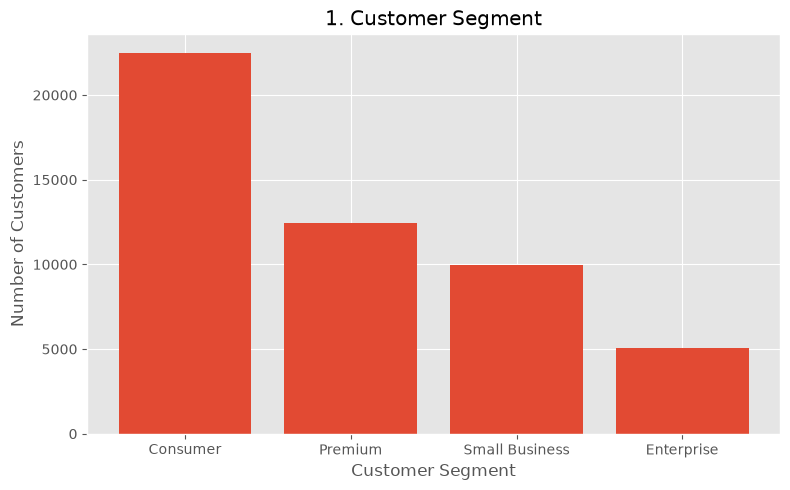

In [58]:
plt.figure(figsize=(8,5))
segment_counts = df["customer_segment"].value_counts()

plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel("Customer Segments")
plt.ylabel("Number of Customers")
plt.title(f'{plot_no}. Customer Segments')
show_fig()
plot_no += 1

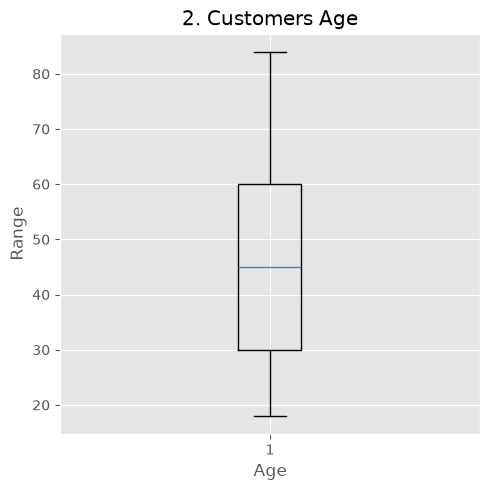

In [63]:
# Outliers
plt.figure(figsize=(5,5))
plt.boxplot(df['age'])
plt.xlabel("Age")
plt.ylabel("Range")
plt.title(f'{plot_no}. Customers Age')
show_fig()
plot_no+=1

In [ ]:
# Outliers in total spending
plt.figure(figsize=(5, 5))
plt.boxplot(df["total_spent_usd"], showfliers=True)

plt.xlabel("Total Spent (USD)")
plt.ylabel("Range")
plt.title(f"{plot_no}. Customer Total Spending")
show_fig()
plot_no += 1